# Tier-3 calibration of one miniPAR against the Li-250A, on the DC-driven LED panel

Fits the **two** per-device parameters of the calibration architecture in
[CALIBRATION.md](CALIBRATION.md):

```
tier 1   x       = raw / (gain x tint)        per sample, no calibration
tier 2   PAR_DEF = w . x                      fleet default, 10 floats   <-- must already be on the device
tier 3   PAR     = a * PAR_DEF + b            per device, 2 floats       <-- this notebook
```

An intensity sweep moves the sample along a single ray in 10-space, so it identifies a scale
and an offset — two parameters — and nothing more. That is exactly tier 3, and it is why this
notebook never touches the ten channel coefficients: fitting those per device is the legacy
failure mode (R² −31 … −7443 on any unseen source family, see CALIBRATION.md).

**On using the LED panel rather than daylight.** Both directions work; daylight is the better
calibrator. Measured across 6 devices:

| tier-3 calibration source | scored on | median \|err\| |
|---|---|---|
| daylight rows | LED panels | 2.4% (0.5–3.1%) |
| LED panels | daylight | 4.4% (2.5–9.8%) |

So calibrating here, expect roughly **4–5% median error in daylight**, worst case ~10%. The
narrow LED spectrum constrains the scale over a small part of `w`'s support, and any error in
`w` on the channels the panel does not excite goes uncorrected. Cross-check against the sky
once before quoting a spec for this unit.

**Hardware assumed** — the rig from `../Scripts/MiniParCallibration.ipynb`:

* miniPAR on USB serial (`hello` → `MiniPAR,<hw>,<fw>`)
* Li-Cor Li-250A read through the micropython TIA board (raw-REPL handshake, then `getPAR()`)
* KIPRIM DC supply (`*IDN?` → `KIPRIM`) driving the LED panel, constant voltage, swept current

In [86]:
import json
import re
import time
import sys
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import serial
import matplotlib.pyplot as plt

# helpers.py stays in ../Scripts: it is shared with the pre-existing notebooks there.
# Only findDevice is used from it. get_MP_name and the other one-shot helpers there open
# and close the port on every call, which resets the miniPAR - see open_quiet below.
sys.path.insert(0, '../Scripts')
from helpers import findDevice

CH = ['f1_415', 'f2_445', 'f3_480', 'f4_515', 'f5_555',
      'f6_590', 'f7_630', 'f8_680', 'clear', 'nir']

_here    = Path.cwd()
DATA_DIR = _here.parent / 'data' if (_here.parent / 'data').is_dir() else _here / 'data'
OUT_DIR  = DATA_DIR / 'data_calibration_minipar'
FLEET    = _here / 'par_coeffs_fleet.json'

BAUD  = 115200
STAMP = datetime.now().strftime('%y%m%d_%H%M%S')

# --- serial plumbing ----------------------------------------------------------------
# The miniPAR is an ESP32 behind a USB-serial bridge whose DTR/RTS lines drive EN/IO0:
# opening the port the ordinary way resets the board, so the reply to the first command is
# a line of boot log rather than the answer ('mode:DIO, clock div:1' is the second-stage
# bootloader announcing its flash mode). Two defences, both needed:
#   open_quiet  - opens with DTR/RTS held low, so the board is not reset in the first place
#   BOOT_LINE   - recognises boot chatter, so mp() can re-send a command the board missed

BOOT_LINE = re.compile(r'^(ESP-ROM|ets\s|rst:|configsip|clk_drv|SPIWP|mode:|load:|entry\s'
                       r'|Build:|\[\s*\d+\]\[|\[spectrometer-debug\]|Spectrometer\s'
                       r'|No BME280|BME280\s|Ready$)')


def open_quiet(port, baud=BAUD, timeout=2.0):
    """Open a port without asserting DTR/RTS, so an ESP32 on the far end keeps running."""
    s = serial.Serial()
    s.port, s.baudrate, s.timeout = port, baud, timeout
    s.dtr = False
    s.rts = False
    s.open()
    return s


def drain(ser, quiet_for=0.5, limit=8.0):
    """Read until the port has been silent for `quiet_for` s. Returns what was read."""
    chunks = []
    last = start = time.monotonic()
    while time.monotonic() - start < limit:
        data = ser.read_all()
        if data:
            chunks.append(data)
            last = time.monotonic()
        elif time.monotonic() - last >= quiet_for:
            break
        time.sleep(0.05)
    return b''.join(chunks).decode(errors='replace')


# --- what is being calibrated, for the record file ----------------------------------
LIGHT_SOURCE = 'LED panel on KIPRIM DC supply, constant 25.0 V, current swept'
OPERATOR     = ''          # optional, goes into the record

# --- the fleet tier-2 vector this device is supposed to be carrying -----------------
fleet = json.loads(FLEET.read_text())
W_FLEET = np.array(fleet['w'], float)
print('tier-2 reference : %s' % FLEET.name)
print('  fit            : %s' % fleet['fit'])
print('  lodo median    : %.2f%%   n=%d over %d devices'
      % (fleet['lodo_median_pct'], fleet['n_samples'], fleet['n_devices']))
if fleet.get('prior_is_placeholder'):
    print('  WARNING: this w is shrunk toward the PLACEHOLDER prior (lambda=%g).'
          % fleet['lambda'])
    print('           Fine for exercising the procedure; regenerate before a production fleet.')


tier-2 reference : par_coeffs_fleet.json
  fit            : lsq_linear, basic_counts vs tia_par, all samples, F1-F8 >= 0, clear/nir free, intercept discarded, shrunk toward W_TARGET at lambda=0.03
  lodo median    : 4.38%   n=462 over 6 devices
           Fine for exercising the procedure; regenerate before a production fleet.


## Step 1 — connect the three instruments

Auto-detection by handshake. Set any of the three `PORT_*` constants by hand if a device is
missed. The TIA board is left in the friendly REPL with its `main.py` loaded, which is what
defines `getPAR()`.

**One handle per instrument, opened once here and kept open.** `findDevice` opens and closes
every candidate port, and each open/close of the miniPAR's port toggles DTR/RTS, which resets
the ESP32. A command sent to a board that is still booting is simply lost, and the "reply" that
comes back is the next line of the boot log - that is where
`par_raw did not return a number: 'mode:DIO, clock div:1'` comes from. The three handles `MP`,
`REF` and `DC` are created in this cell and reused by every cell below; nothing downstream
opens a port of its own.

Re-run this cell to reconnect - it closes the old handles first. To release the ports without
restarting the kernel: `for h in (MP, REF, DC): h.close()`.


In [87]:
PORT_MINIPAR = None       # e.g. 'COM7'
PORT_DC      = None
PORT_REF     = None

# Close handles left by an earlier run of this cell, or the re-open below fails on Windows.
for _name in ('MP', 'REF', 'DC'):
    _old = globals().get(_name)
    if isinstance(_old, serial.Serial) and _old.is_open:
        _old.close()

if PORT_MINIPAR is None:
    PORT_MINIPAR = findDevice(question='hello\n', answer='MiniPAR', flush=True, timeout=2)
if PORT_DC is None:
    PORT_DC = findDevice(question='*IDN?\n', answer='KIPRIM', flush=True, timeout=2)
if PORT_REF is None:
    # Ctrl-C, Ctrl-C, THEN Ctrl-A. findDevice pokes every port with every question, so the
    # miniPAR probe above has just left 'hello' in this board's readline buffer - and
    # Ctrl-A on a non-empty line only moves the cursor, it does not enter the raw REPL.
    # The symptom is a reply of '\x1b[5D' instead of 'raw REPL; CTRL-B to exit'.
    # Ctrl-C abandons the pending line first, so the probe starts from a clean prompt.
    PORT_REF = findDevice(question='\x03\x03\x01', answer='raw', flush=True, timeout=2)

for label, prt in (('miniPAR', PORT_MINIPAR), ('DC supply', PORT_DC),
                   ('Li-250A TIA', PORT_REF)):
    print('%-12s %s' % (label, prt if prt else '<-- NOT FOUND'))

if not (PORT_MINIPAR and PORT_DC and PORT_REF):
    # findDevice can only report what serial_ports() managed to open, which hides the two
    # cases worth telling apart: a device absent from the USB bus (cable, hub, or firmware
    # that never brought its CDC up) versus a port held open by another process (a serial
    # monitor, or an earlier kernel of this notebook).
    import serial.tools.list_ports as _lp
    print('\nUSB serial devices Windows can see:')
    for _p in sorted(_lp.comports(), key=lambda q: q.device):
        try:
            serial.Serial(_p.device, timeout=0.2).close()
            _state = 'free'
        except Exception as _exc:
            _state = '%s: %s' % (type(_exc).__name__, str(_exc)[:60])
        print('  %-7s %-30s %-26s %s'
              % (_p.device, (_p.description or '')[:30], _p.hwid[:26], _state))
    print('\nNo Espressif VID (303A) in that list means the miniPAR is not on the bus at\n'
          'all - check cable and hub port, then whether that unit is flashed and running.\n'
          'A port listed but not free is held by another process; close it and re-run.')

assert PORT_MINIPAR and PORT_DC and PORT_REF, 'set the missing PORT_* by hand and re-run'

MP  = open_quiet(PORT_MINIPAR, timeout=2.0)
REF = open_quiet(PORT_REF, timeout=3.0)
DC  = open_quiet(PORT_DC, timeout=1.0)

# findDevice's last close reset the miniPAR: wait the boot log out before talking to it.
boot = drain(MP, quiet_for=0.6, limit=8.0)
print('\nminiPAR   : %d bytes of boot log drained, ends %s'
      % (len(boot), boot.strip().splitlines()[-1:]))

# Ctrl-B back to the friendly REPL, Ctrl-D soft reboot so main.py runs and getPAR() exists.
REF.write('\x02\x04'.encode())
REF.flush()
banner = drain(REF, quiet_for=0.6, limit=8.0)
print('TIA banner:', banner.strip().splitlines()[-1:])


Received message: , port: COM4
Received message: MiniPAR,1.1,1.06, port: COM64
Found device at: COM64, answer: MiniPAR,1.1,1.06

Received message: KIPRIM,DC310S,25011669,FV:V5.2.0, port: COM4
Found device at: COM4, answer: KIPRIM,DC310S,25011669,FV:V5.2.0

Received message: , port: COM4
Received message: , port: COM64
Received message: >>> 
>>> 
raw REPL; CTRL-B to exit
>, port: COM66
Found device at: COM66, answer: 
>>> 
>>> 
raw REPL; CTRL-B to exit
>
miniPAR      COM64
DC supply    COM4
Li-250A TIA  COM66

miniPAR   : 0 bytes of boot log drained, ends []
TIA banner: ['>>>']


In [88]:
# --- device I/O ---------------------------------------------------------------------
# Every plain-mode miniPAR reply is newline-terminated (main.cpp prints Serial.println()
# after each command), so readline() is enough. All of these talk over the handles opened
# in step 1 and never open a port themselves: a fresh open resets the board and the reply
# would be boot chatter. Pass `ser` only to address a second board.

def mp(cmd, ser=None, retries=2):
    """Send one plain-text command to the miniPAR, return its reply as a string.

    Boot-log lines are skipped rather than returned. If the board did reset it never saw
    the command, so the command is re-sent once the log has stopped.
    """
    ser = MP if ser is None else ser
    for attempt in range(retries + 1):
        ser.reset_input_buffer()
        ser.write((cmd + '\n').encode())
        ser.flush()
        booting = False
        while True:
            r = ser.readline().decode(errors='replace').strip()
            if not r:
                break                       # readline timed out, nothing more is coming
            if BOOT_LINE.match(r):
                booting = True              # the board rebooted, so the command is lost
                continue
            return r
        if booting:
            drain(ser, quiet_for=0.5, limit=8.0)     # let the rest of the boot log out
        time.sleep(0.2)
    raise IOError('no reply to %r' % cmd)


def mp_float(cmd, ser=None):
    r = mp(cmd, ser)
    try:
        return float(r)
    except ValueError:
        raise IOError('%s did not return a number: %r' % (cmd, r))


def mp_par_raw(ser=None):
    """Tier-2 output: w . basic_counts. Independent of gain and integration time."""
    return mp_float('par_raw', ser)


def mp_par(ser=None):
    """Deployed value: a * par_raw + b, with whatever a, b are on the device now."""
    return mp_float('par', ser)


def mp_status(ser=None):
    """spec_status -> dict, e.g. {'model': 'AS7341', 'atime': '100', 'gain': '2', ...}"""
    return dict(kv.split('=', 1) for kv in mp('spec_status', ser).split(',') if '=' in kv)


def mp_sat(ser=None):
    """spec_sat -> (kind, full_scale). kind is 'none' when the reading is usable."""
    parts = mp('spec_sat', ser).split(',')
    kind = parts[1] if len(parts) > 1 else 'unknown'
    full = int(parts[3]) if len(parts) > 3 and parts[3].isdigit() else None
    return kind, full


def mp_coeffs(ser=None):
    """The 18 tier-2 coefficients currently in RAM/NVS on the device.

    Line mode answers a bare `get_spec_coeff` with 18 comma-separated floats at 6
    decimals - the {"spectrometer_coeffs": ...} object is the jsonMode branch only
    (commands.cpp). The JSON path is kept as a fallback for a device left in JSON mode.
    """
    r = mp('get_spec_coeff', ser)
    if r.lstrip().startswith('{'):
        d = json.loads(r)['spectrometer_coeffs']['channels']
        return np.array([d[str(i)] for i in range(18)], float)
    try:
        v = np.array([float(x) for x in r.split(',')], float)
    except ValueError:
        raise IOError('get_spec_coeff returned %r' % r)
    if v.size != 18:
        raise IOError('get_spec_coeff returned %d values, expected 18: %r' % (v.size, r))
    return v


def mp_get_cal(ser=None):
    """get_cal_par -> (slope, intercept)."""
    kv = dict(p.split('=', 1) for p in mp('get_cal_par', ser).split(',') if '=' in p)
    return float(kv['slope']), float(kv['intercept'])


def ref_par(ser=None):
    """Li-250A via the TIA board. The friendly REPL echoes the call, so skip one line."""
    ser = REF if ser is None else ser
    ser.reset_input_buffer()
    ser.write('getPAR()\r'.encode())
    ser.flush()
    ser.readline()                                  # echo
    return float(ser.readline())


MAC_QUERY = '[{"set":[{"label":"hello"}]}]'     # cheapest JSON frame that carries device_id


def device_mac(sep=''):
    """The MAC as the JSON frame header reports it, joined with `sep`. Line mode has no
    command for it, so this sends one JSON frame; the reply ends in a newline
    (commands.cpp serial_string_end), so readline() is enough."""
    MP.reset_input_buffer()
    MP.write(MAC_QUERY.encode())
    MP.flush()
    frame = MP.readline().decode(errors='replace')
    m = re.search(r'"device_id"\s*:\s*"([^"]+)"', frame)
    if not m:
        raise IOError('no device_id in the JSON frame: %r' % frame.strip())
    return sep.join(m.group(1).split(':'))


def dc_set(current=None, voltage=None):
    """KIPRIM supply. Voltage is set once; the sweep varies current."""
    if voltage is not None:
        DC.write(('voltage %.3f\r\n' % voltage).encode())
        DC.flush()
        time.sleep(0.1)
    if current is not None:
        DC.write(('current %.3f\r\n' % current).encode())
        DC.flush()


DEVICE = mp('get_name') or 'unnamed'
HELLO  = mp('hello')
FW     = HELLO.split(',')[2] if HELLO.count(',') >= 2 else '?'

# The MAC is what identifies the unit no matter how it was named, so it is read once here
# and goes into the record file in step 7. A device that cannot answer is not fatal.
try:
    MAC = device_mac()
except (IOError, ValueError) as exc:
    MAC = ''
    print('MAC     : unavailable (%s)' % exc)

print('device  : %s   (%s)' % (DEVICE, HELLO))
if MAC:
    print('MAC     : %s' % ':'.join(re.findall('..', MAC)))
print('par_raw : %.4f' % mp_par_raw())
print('Li-250A : %.2f umol/m2/s' % ref_par())


device  : Par_REF   (MiniPAR,1.1,1.06)
MAC     : 3C:DC:75:0C:05:04
par_raw : 5.5100
Li-250A : 5.49 umol/m2/s


## Step 1A — name this device

The name labels the record file, the figure, and every later reference to this unit, so it is
set before calibrating rather than after. Type one at the prompt, or leave it blank and the
device is named after its own MAC. `set_name` persists to NVS (`par_coeffs/name`).

**19 characters, and `miniPAR_<MAC>` is 20.** The firmware stores the name in
`char dev_name[20]` and writes it with `strncpy(..., sizeof(dev_name) - 1)`, so anything longer
is silently cut. `miniPAR_` plus the 12 hex digits of the MAC is one character over, so the
derived name drops the **leading** digit: those are the shared Espressif OUI, while the trailing
digits are what tells two boards apart — cutting the tail is how two units end up with the same
name. `miniPAR_3C:DC:75:0C:04:F4` therefore becomes `miniPAR_CDC750C04F4`.

The MAC comes from the JSON frame header (`device_id`); line mode has no command for it. Note
this differs from the dataset's `miniPAR_3CDC750C04F4` labels, which are composed host-side and
never went through `set_name`.

In [89]:
NEW_NAME = input("insert name device, if empty named as miniPAR_{MACID}")         # empty -> miniPAR_<MAC>
MAX_NAME = 19         # char dev_name[20] in spectrometer_api.cpp, one byte for the terminator


def mac_name(mac):
    """miniPAR_<MAC>, trimmed from the LEFT to the 19 bytes the firmware keeps."""
    return 'miniPAR_' + mac[-(MAX_NAME - len('miniPAR_')):]


NEW_NAME = NEW_NAME.strip()
if not NEW_NAME:
    assert MAC, 'the device did not report a MAC - type a name instead'
    NEW_NAME = mac_name(MAC)
    print('no name given -> from the MAC : %r' % NEW_NAME)

assert ',' not in NEW_NAME, 'a comma would be read as the argument separator'
if len(NEW_NAME) > MAX_NAME:
    print('WARNING: %d characters - the device will keep only the first %d'
          % (len(NEW_NAME), MAX_NAME))

print('was           : %r' % DEVICE)
print('set_name      : %r' % mp('set_name,%s' % NEW_NAME))
DEVICE = mp('get_name')                  # everything downstream labels itself with this
print('read back     : %r' % DEVICE)
assert DEVICE == NEW_NAME[:MAX_NAME], 'device stored %r, expected %r' % (DEVICE,
                                                                        NEW_NAME[:MAX_NAME])
if DEVICE != NEW_NAME:
    print('truncated to fit dev_name[20] - shorten the name if that is not what you want')


was           : 'Par_REF'
set_name      : 'Par_REF'
read back     : 'Par_REF'


## Step 2 — preflight: is tier 2 on this device the fleet vector?

`par_raw` is `w · basic_counts` using whatever coefficients the device has in NVS, so tier 3
is only meaningful once `w` is the fleet vector. Three things are checked:

* **firmware ≥ 1.06** — earlier builds divide by seconds, making their basic counts 1000× the
  host's, and `par_raw` with it;
* **channels 0–9 match `par_coeffs_fleet.json`** — a device that went through the legacy flow
  carries per-device coefficients in NVS that shadow the header defaults;
* **channels 10–17 are zero** and the current `slope`/`intercept` are recorded before being
  overwritten.

In [90]:
dev_coeffs = mp_coeffs()
slope0, intercept0 = mp_get_cal()

fw_ok = tuple(int(v) for v in FW.split('.')) >= (1, 6) if FW.replace('.', '').isdigit() else False
# get_spec_coeff prints 6 decimals, so compare with a tolerance rather than exactly.
rel   = np.abs(dev_coeffs[:10] - W_FLEET) / np.maximum(np.abs(W_FLEET), 1e-12)
w_ok  = bool(np.all(rel < 1e-4))
tail_ok = bool(np.all(dev_coeffs[10:] == 0))

print('firmware            : %s   %s' % (FW, 'ok' if fw_ok else '<-- needs >= 1.06, re-flash'))
print('tier-3 on device now: slope=%.6g  intercept=%.6g' % (slope0, intercept0))
print('channels 10-17 zero : %s' % ('yes' if tail_ok else 'NO <-- unexpected, inspect'))
print('\n%-8s %14s %14s %10s' % ('channel', 'on device', 'fleet w', 'rel.diff'))
for c, dv, wv, r in zip(CH, dev_coeffs[:10], W_FLEET, rel):
    print('%-8s %14.6f %14.6f %9.1e%s'
          % (c, dv, wv, r, '' if r < 1e-4 else '   <-- differs'))

if w_ok and fw_ok:
    print('\nTier 2 matches the fleet vector. Proceed to step 3.')
else:
    print('\nSTOP: fix tier 2 (next cell) or the firmware before fitting tier 3.')

firmware            : 1.06   ok
tier-3 on device now: slope=0.890771  intercept=0.684319
channels 10-17 zero : yes

channel       on device        fleet w   rel.diff
f1_415       614.748901      40.806303   1.4e+01   <-- differs
f2_445        53.050953      42.178012   2.6e-01   <-- differs
f3_480       110.521400      69.849365   5.8e-01   <-- differs
f4_515        92.515923      85.874869   7.7e-02   <-- differs
f5_555       105.122925      61.895589   7.0e-01   <-- differs
f6_590        72.988022      43.742399   6.7e-01   <-- differs
f7_630        94.636108      51.571380   8.4e-01   <-- differs
f8_680        35.703251      14.705461   1.4e+00   <-- differs
clear        -60.620304      19.308320   4.1e+00   <-- differs
nir           -1.708217     -27.252600   9.4e-01   <-- differs

STOP: fix tier 2 (next cell) or the firmware before fitting tier 3.


Upload the fleet `w` only if the table above shows a mismatch. It writes NVS on the device
(`set_spec_coeff` persists), which invalidates any existing `slope`/`intercept` — so always
re-run the sweep afterwards. Guarded deliberately: flip the flag to arm it.

In [91]:
UPLOAD_TIER2 = True        # set True to write the fleet w into this device's NVS

if UPLOAD_TIER2:
    if fleet.get('prior_is_placeholder'):
        print('note: writing a w shrunk toward the placeholder prior\n')
    for i, v in enumerate(W_FLEET):
        print('ch%-2d -> %s' % (i, mp('set_spec_coeff,%d,%.9g' % (i, v))))
        time.sleep(0.05)
    dev_coeffs = mp_coeffs()
    rel  = np.abs(dev_coeffs[:10] - W_FLEET) / np.maximum(np.abs(W_FLEET), 1e-12)
    w_ok = bool(np.all(rel < 1e-4))
    print('\nread back: %s (max rel.diff %.1e)' % ('matches' if w_ok else 'MISMATCH', rel.max()))
    print('slope/intercept are now stale - continue to the sweep.')
else:
    print('skipped (UPLOAD_TIER2 is False)')


note: writing a w shrunk toward the placeholder prior

ch0  -> {"spectrometer_coeff":{"channel":0,"value":40.806301}}
ch1  -> {"spectrometer_coeff":{"channel":1,"value":42.178013}}
ch2  -> {"spectrometer_coeff":{"channel":2,"value":69.849365}}
ch3  -> {"spectrometer_coeff":{"channel":3,"value":85.874870}}
ch4  -> {"spectrometer_coeff":{"channel":4,"value":61.895588}}
ch5  -> {"spectrometer_coeff":{"channel":5,"value":43.742397}}
ch6  -> {"spectrometer_coeff":{"channel":6,"value":51.571381}}
ch7  -> {"spectrometer_coeff":{"channel":7,"value":14.705462}}
ch8  -> {"spectrometer_coeff":{"channel":8,"value":19.308319}}
ch9  -> {"spectrometer_coeff":{"channel":9,"value":-27.252600}}

read back: matches (max rel.diff 4.6e-08)
slope/intercept are now stale - continue to the sweep.


## Step 3 — exposure headroom at the top of the sweep

A saturated channel silently truncates `par_raw` and would be fitted as if it were real. Since
`par_raw` is gain/integration-time invariant, lowering the gain costs nothing here: it only
buys headroom. The cell drives the panel to the brightest current in the sweep and steps the
gain index down until `spec_sat` reports `none`.

In [92]:
CURRENTS_UP = [0.0, 0.2, 0.4, 0.8, 1.2, 1.6]     # A, the fit leg; keep the dark point
SETTLE_S    = 4.0                                 # after a current change, before reading
REPEATS     = 5                                   # reads per level, median is used

dc_set(voltage=25.0, current=0.0)
time.sleep(1.0)
dc_set(current=max(CURRENTS_UP))
time.sleep(SETTLE_S)

st = mp_status()
gain = int(st.get('gain', 0))
kind, full = mp_sat()
print('at %.2f A: gain index %d, atime %s, astep %s -> saturation: %s'
      % (max(CURRENTS_UP), gain, st.get('atime'), st.get('astep'), kind))

while kind != 'none' and gain > 0:
    gain -= 1
    print('  saturated, dropping gain index to %d: %s' % (gain, mp('spec_set_gain,%d' % gain)))
    time.sleep(0.5)
    kind, full = mp_sat()
    print('  -> saturation: %s' % kind)

EXPOSURE = mp_status()
dc_set(current=0.0)
print('\nexposure for the sweep: %s' % EXPOSURE)
assert kind == 'none', 'still saturated at gain index 0 - reduce atime/astep or the panel current'

at 1.60 A: gain index 2, atime 100, astep 999 -> saturation: none

exposure for the sweep: {'model': 'AS7341', 'available': '1', 'atime': '100', 'astep': '999', 'gain': '2'}


## Step 4 — the sweep, up then back down

The panel is driven up through the currents and then back down through the same ones. The
**up** leg fits `(a, b)`; the **down** leg is held out, so the validation is on points the fit
never saw and any thermal drift or hysteresis in the panel shows up as a split between the
legs rather than hiding inside the residuals.

At each level the Li-250A and the miniPAR are read back to back, `REPEATS` times, and the
medians are kept — the two instruments see the same light at the same moment, so slow panel
drift cancels instead of turning into scatter.

In [93]:
LEVELS = ([(c, 'up') for c in CURRENTS_UP] +
          [(c, 'down') for c in reversed(CURRENTS_UP)])

rows = []
try:
    for k, (I, leg) in enumerate(LEVELS):
        dc_set(current=I)
        time.sleep(SETTLE_S)
        refs, raws = [], []
        for _ in range(REPEATS):
            refs.append(ref_par())                # back to back, same light
            raws.append(mp_par_raw())
        kind, _ = mp_sat()
        rows.append(dict(current_a=I, leg=leg, order=k,
                         ref=float(np.median(refs)), ref_sd=float(np.std(refs)),
                         par_raw=float(np.median(raws)), raw_sd=float(np.std(raws)),
                         sat=kind, t=datetime.now().isoformat(timespec='seconds')))
        print('%-4s %.2f A   ref %8.2f +-%5.2f   par_raw %9.4f +-%7.4f   sat=%s'
              % (leg, I, rows[-1]['ref'], rows[-1]['ref_sd'],
                 rows[-1]['par_raw'], rows[-1]['raw_sd'], kind))
finally:
    dc_set(current=0.0)

sweep = pd.DataFrame(rows)
bad = sweep[sweep.sat != 'none']
if len(bad):
    print('\nSATURATED at %s A - those rows must not be fitted.'
          % ', '.join('%.2f' % c for c in bad.current_a))


up   0.00 A   ref     5.49 +- 0.00   par_raw    4.6900 +- 0.0000   sat=none
up   0.20 A   ref    17.30 +- 0.01   par_raw   16.4700 +- 0.0000   sat=none
up   0.40 A   ref    30.26 +- 0.01   par_raw   29.2600 +- 0.0490   sat=none
up   0.80 A   ref    56.25 +- 0.02   par_raw   55.0500 +- 0.0000   sat=none
up   1.20 A   ref    81.96 +- 0.02   par_raw   80.5500 +- 0.0000   sat=none
up   1.60 A   ref   107.30 +- 0.01   par_raw  105.3800 +- 0.0508   sat=none
down 1.60 A   ref   107.16 +- 0.02   par_raw  105.1900 +- 0.0826   sat=none
down 1.20 A   ref    81.80 +- 0.01   par_raw   80.2700 +- 0.0000   sat=none
down 0.80 A   ref    56.13 +- 0.01   par_raw   55.0100 +- 0.0200   sat=none
down 0.40 A   ref    30.17 +- 0.01   par_raw   29.2000 +- 0.0000   sat=none
down 0.20 A   ref    17.23 +- 0.01   par_raw   16.4700 +- 0.0200   sat=none
down 0.00 A   ref     5.42 +- 0.00   par_raw    4.6900 +- 0.0000   sat=none


## Step 5 — fit on the up leg, validate on the down leg

`ref = a · par_raw + b`, ordinary least squares, intercept fitted. Tier 3 owns the intercept:
composing the tiers gives `PAR = a·(w·x) + (a·b₀ + b)`, which is why tier 2 discards its own.

A large `|b|` relative to the brightest reading is the diagnostic worth reading — it points at
stray light or a dark-offset problem rather than a scale error.

slope     a = 1.0106
intercept b = 0.676424   (0.6% of the brightest reading, 107.3 umol)

                          n  lit        R2   med|err|   max|err|
up leg (fitted)           6    6   0.99999      0.12%      1.34%
down leg (held out)       6    6   0.99999      0.13%      0.53%


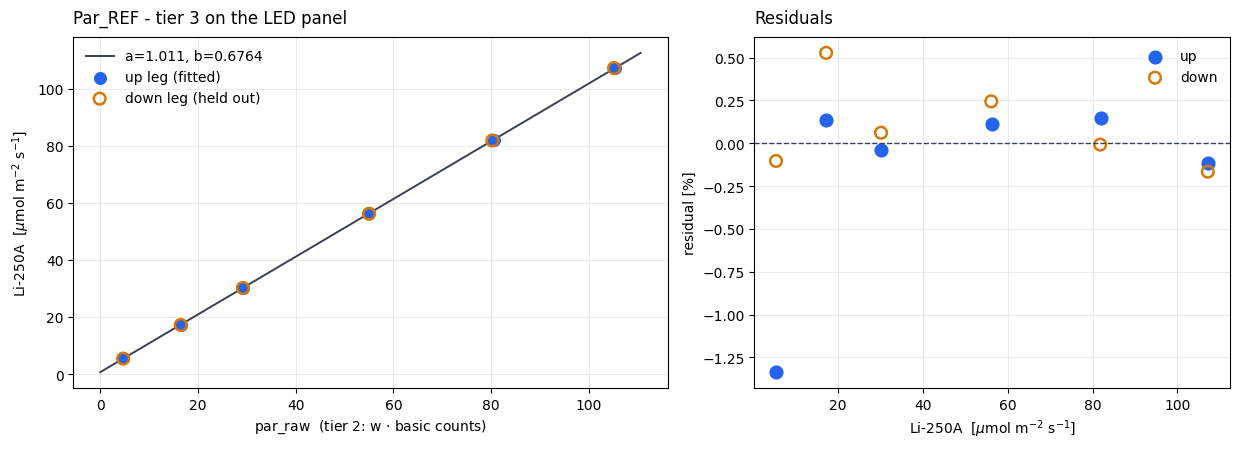

In [94]:
fitset = sweep[(sweep.leg == 'up') & (sweep.sat == 'none')]
heldout = sweep[(sweep.leg == 'down') & (sweep.sat == 'none')]
assert fitset.current_a.nunique() >= 4, 'need at least 4 clean levels to fit'

a, b = np.polyfit(fitset.par_raw, fitset.ref, 1)


# A percentage error against a ~1 umol dark reading is division noise, not accuracy, so the
# percentage metrics cover only levels above LIT_FRAC of the brightest one. R2 uses every point.
LIT_FRAC = 0.05


def score(d):
    """Predicted vs measured on rows `d`, with the fitted a, b."""
    p = a * d.par_raw.to_numpy() + b
    y = d.ref.to_numpy()
    lit = y > LIT_FRAC * sweep.ref.max()
    ss = np.sum((y - p) ** 2), np.sum((y - y.mean()) ** 2)
    return dict(n=len(d), n_lit=int(lit.sum()),
                r2=1 - ss[0] / ss[1] if ss[1] else float('nan'),
                med_pct=float(np.median(np.abs(p[lit] - y[lit]) / y[lit] * 100)),
                max_pct=float(np.max(np.abs(p[lit] - y[lit]) / y[lit] * 100)),
                lit=lit, pred=p, resid=p - y)

up, down = score(fitset), score(heldout)
bright = sweep.ref.max()

print('slope     a = %.6g' % a)
print('intercept b = %.6g   (%.1f%% of the brightest reading, %.1f umol)'
      % (b, abs(b) / bright * 100, bright))
print('\n%-22s %4s %4s %9s %10s %10s'
      % ('', 'n', 'lit', 'R2', 'med|err|', 'max|err|'))
for name, s in (('up leg (fitted)', up), ('down leg (held out)', down)):
    print('%-22s %4d %4d %9.5f %9.2f%% %9.2f%%'
          % (name, s['n'], s['n_lit'], s['r2'], s['med_pct'], s['max_pct']))
if abs(b) / bright > 0.02:
    print('\nNOTE: |b| is >2%% of full reading - check for stray light or a dark offset.')
if down['med_pct'] > 2 * max(up['med_pct'], 0.1):
    print('\nNOTE: the held-out leg is much worse than the fitted one - panel drift or '
          'hysteresis. Lengthen SETTLE_S and re-run.')

# --- figure ------------------------------------------------------------------------
C_UP, C_DN, INK, GRID = '#2563eb', '#d97706', '#374151', '#e5e7eb'
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 4.6),
                               gridspec_kw=dict(width_ratios=[1.25, 1]))

xs = np.linspace(0, sweep.par_raw.max() * 1.05, 200)
axA.plot(xs, a * xs + b, color=INK, lw=1.4, zorder=1,
         label='a=%.4g, b=%.4g' % (a, b))
axA.scatter(fitset.par_raw, fitset.ref, s=70, color=C_UP, zorder=3, label='up leg (fitted)')
axA.scatter(heldout.par_raw, heldout.ref, s=70, facecolor='none', edgecolor=C_DN,
            lw=1.8, zorder=3, label='down leg (held out)')
axA.set_xlabel('par_raw  (tier 2: w $\\cdot$ basic counts)')
axA.set_ylabel('Li-250A  [$\\mu$mol m$^{-2}$ s$^{-1}$]')
axA.set_title('%s - tier 3 on the LED panel' % DEVICE, loc='left', pad=10)
axA.legend(frameon=False, loc='upper left')
axA.grid(True, color=GRID, lw=0.6)
axA.set_axisbelow(True)

for d, s, colour, name in ((fitset, up, C_UP, 'up'), (heldout, down, C_DN, 'down')):
    lit = s['lit']                      # the same mask score() reported on
    axB.scatter(d.ref.to_numpy()[lit], (s['resid'][lit] / d.ref.to_numpy()[lit]) * 100,
                s=70, color=colour, label=name,
                facecolor=colour if name == 'up' else 'none',
                edgecolor=colour, lw=1.8)
axB.axhline(0, color=INK, lw=1.0, ls='--')
axB.set_xlabel('Li-250A  [$\\mu$mol m$^{-2}$ s$^{-1}$]')
axB.set_ylabel('residual [%]')
axB.set_title('Residuals', loc='left', pad=10)
axB.legend(frameon=False)
axB.grid(True, color=GRID, lw=0.6)
axB.set_axisbelow(True)

fig.tight_layout()
plt.show()

## Step 6 — upload, read back, and check at levels that were never fitted

`cal_par_slope` / `cal_par_intercept` persist to NVS and take effect immediately. Guarded the
same way as the tier-2 write.

In [95]:
UPLOAD_TIER3 = True        # set True to write a, b into this device's NVS

if UPLOAD_TIER3:
    print(mp('cal_par_slope,%.6g' % a))
    time.sleep(0.3)
    print(mp('cal_par_intercept,%.6g' % b))
    slope1, intercept1 = mp_get_cal()
    print('\nread back : slope=%.6g  intercept=%.6g' % (slope1, intercept1))
    ok = abs(slope1 - a) <= 1e-5 * max(abs(a), 1) and abs(intercept1 - b) <= 1e-5 * max(abs(b), 1)
    print('matches fit: %s  (device stores 6 significant digits)' % ok)
else:
    slope1, intercept1 = slope0, intercept0
    print('skipped (UPLOAD_TIER3 is False) - the check below would test the OLD a, b')


1.01
0.68

read back : slope=1.0106  intercept=0.676424
matches fit: True  (device stores 6 significant digits)


In [96]:
# Currents deliberately between the swept levels, so `par` is scored where nothing was fitted.
CHECK_CURRENTS = [0.3, 0.6, 1.0, 1.4]

checks = []
try:
    print('%8s %10s %10s %9s' % ('current', 'Li-250A', 'par', 'err'))
    for I in CHECK_CURRENTS:
        dc_set(current=I)
        time.sleep(SETTLE_S)
        r = float(np.median([ref_par() for _ in range(REPEATS)]))
        p = float(np.median([mp_par() for _ in range(REPEATS)]))
        checks.append(dict(current_a=I, ref=r, par=p,
                           err_pct=(p - r) / r * 100 if r > 1 else float('nan')))
        print('%7.2fA %10.2f %10.2f %8.2f%%' % (I, r, p, checks[-1]['err_pct']))
finally:
    dc_set(current=0.0)

check = pd.DataFrame(checks)
print('\nmedian |err| at unfitted levels: %.2f%%' % check.err_pct.abs().median())
print('This is the same spectrum the fit used, so it validates the scale and the panel\'s'
      ' repeatability - not the spectral transfer. Expect ~4-5% in daylight.')


 current    Li-250A        par       err
   0.30A      23.71      23.87     0.67%
   0.60A      43.17      43.36     0.43%
   1.00A      69.00      68.97    -0.05%
   1.40A      94.61      94.42    -0.20%

median |err| at unfitted levels: 0.32%
This is the same spectrum the fit used, so it validates the scale and the panel's repeatability - not the spectral transfer. Expect ~4-5% in daylight.


## Step 7 — record what was done

One file per calibration run, keyed by device and timestamp, written under `../data/data_calibration_minipar/`
(`data/` is gitignored, so these stay local). It carries the tier-2 vector the fit was made
against — without it, `a` and `b` mean nothing.

In [97]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
base = OUT_DIR / ('tier3_%s_%s' % (DEVICE.replace(' ', '_'), STAMP))

record = {
    'device': DEVICE, 'device_mac': MAC or None, 'hello': HELLO, 'firmware': FW,
    'timestamp': datetime.now().isoformat(timespec='seconds'),
    'operator': OPERATOR,
    'light_source': LIGHT_SOURCE,
    'reference': 'Li-Cor Li-250A via micropython TIA board',
    'exposure': EXPOSURE,
    'tier2': {'source': FLEET.name, 'fit': fleet['fit'], 'lambda': fleet.get('lambda'),
              'prior_is_placeholder': fleet.get('prior_is_placeholder'),
              'w': W_FLEET.tolist(), 'verified_on_device': w_ok},
    'tier3': {'slope': float(a), 'intercept': float(b),
              'uploaded': bool(UPLOAD_TIER3),
              'previous': {'slope': slope0, 'intercept': intercept0}},
    'fit': {'levels_a': CURRENTS_UP, 'settle_s': SETTLE_S, 'repeats': REPEATS,
            'up':   {k: up[k]   for k in ('n', 'r2', 'med_pct', 'max_pct')},
            'down': {k: down[k] for k in ('n', 'r2', 'med_pct', 'max_pct')}},
    'check': {'currents_a': CHECK_CURRENTS,
              'median_abs_err_pct': float(check.err_pct.abs().median()),
              'rows': checks},
    'expected_daylight_err_pct': 4.4,      # CALIBRATION.md, LED-calibrated -> daylight
}

base.with_suffix('.json').write_text(json.dumps(record, indent=2))
sweep.to_csv(base.with_name(base.name + '_sweep.csv'), index=False)
fig.savefig(base.with_name(base.name + '_fit.png'), dpi=150, bbox_inches='tight')
print('saved:')
for p in sorted(OUT_DIR.glob(base.name + '*')):
    print('  %s' % p)

saved:
  c:\Users\LudovicoCaracciolo\Documents\Git-repo\miniPar\data\data_calibration_minipar\tier3_Par_REF_260818_152652.json
  c:\Users\LudovicoCaracciolo\Documents\Git-repo\miniPar\data\data_calibration_minipar\tier3_Par_REF_260818_152652_fit.png
  c:\Users\LudovicoCaracciolo\Documents\Git-repo\miniPar\data\data_calibration_minipar\tier3_Par_REF_260818_152652_sweep.csv


## What this run does and does not establish

**Established** — the two per-device parameters, and that `par` tracks the Li-250A on this
panel at levels that were not fitted, with the panel's own repeatability folded in.

**Not established** — the spectral transfer. Tier 2's `w` is fleet-wide and was fitted on a
daylight-dominated set; this sweep constrains only the scale along the panel's spectrum. The
measured cost of calibrating this way is a median 4.4% in daylight, up to 9.8% on the worst of
six devices (CALIBRATION.md).

**Worth doing next**, in order of value:

1. one outdoor reading against the Li-250A as a cross-check — if it disagrees by much more
   than ~10%, suspect tier 2 on this device rather than `a` and `b`;
2. re-run this sweep after any `set_spec_coeff` write, since `a` and `b` are only valid for
   the `w` they were fitted against;
3. regenerate `par_coeffs_fleet.json` with the CM-derived prior before quoting a fleet spec —
   the current export is shrunk toward a placeholder.